# PROJECT TITLE

- HOUSE PRICE PREDICTION USING MACHINE LEARNING

# LEVEL 1- TASK 2

DATA  CLEANING  AND and PREPROCESSING


# Step 1: Import Libraries

In [ ]:

# HOUSE PRICE PREDICTION PROJECT
# Level 1 - Task 2
# Data Cleaning and Preprocessing

# Import Data Manipulation Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# STEP 2: Upload Dataset

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
import pandas as pd

# Define the path to the folder
Codveda_folder_path = '/content/drive/My Drive/Codveda'

# Check files
files_in_Codveda = os.listdir(Codveda_folder_path)
print(files_in_Codveda)

# Combine the folder path with the specific CSV file name
file_path = os.path.join(Codveda_folder_path, 'Housing.csv')

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

['Housing.csv', 'House_Prices_Cleaned.csv']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
#STEP 4: Display the Last Rows

# Display last five rows
df.tail()


# STEP 5: Check Dataset Shape

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")


# STEP 6: Display Column Names

df.columns


# STEP 7: Dataset Information

df.info()


Number of Rows: 545
Number of Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:

# STEP 8: Statistical Summary

# Numerical Features

df.describe()



# Categorical Features

df.describe(include="object")



,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [ ]:
# STEP 9: Check Missing Values

missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)



# STEP 10: Percentage of Missing Values

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0].sort_values(ascending=False)



,0


In [ ]:
# STEP 11: Visualize Missing Values

plt.figure(figsize=(14,8))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()


In [ ]:

# STEP 12: Check Duplicate Records

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

# If duplicates exist:

df = df.drop_duplicates()

print("Duplicate records removed successfully.")


Duplicate Rows: 0
Duplicate records removed successfully.


In [ ]:
# STEP 13: Check Data Types

df.dtypes


# STEP 14: Separate Numerical and Categorical Features

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

categorical_features = df.select_dtypes(include=["object"]).columns

print("Number of Numerical Features:", len(numerical_features))

print("Number of Categorical Features:", len(categorical_features))


Number of Numerical Features: 6
Number of Categorical Features: 7


In [ ]:
# STEP 15: Display Numerical Features

numerical_features


# STEP 16: Display Categorical Features

categorical_features

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

# HOUSE PRICE PREDICTION PROJECT

# Level 1 – Task 2: Data Cleaning & Preprocessing


In [ ]:
# STEP 17: Handle Missing Values

# Check missing values

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)


,0


In [ ]:

# STEP 18: Calculate Missing Value Percentage

# Percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)


,0


In [ ]:
# STEP 19: Drop columns with more than 40% missing values

threshold = 40

columns_to_drop = missing_percentage[
    missing_percentage > threshold
].index

df.drop(columns=columns_to_drop, inplace=True)

print("Dropped Columns:")
print(columns_to_drop)


Dropped Columns:
Index([], dtype='object')


In [ ]:

# STEP 20: Fill Missing Values in Numerical Columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:
        df[column].fillna(
                df[column].median(),
                        inplace=True
       )


In [ ]:

# STEP 21: Fill missing values in categorical columns

categorical_columns = df.select_dtypes(
    include=["object"]
    ).columns

for column in categorical_columns:
    df[column].fillna(
        df[column].mode()[0],
        inplace=True
    )


In [ ]:

# STEP 22: To Confirm that all missing values have been handled

df.isnull().sum().sum()


# STEP 23: Check Dataset Shape

print(df.shape)


(545, 13)


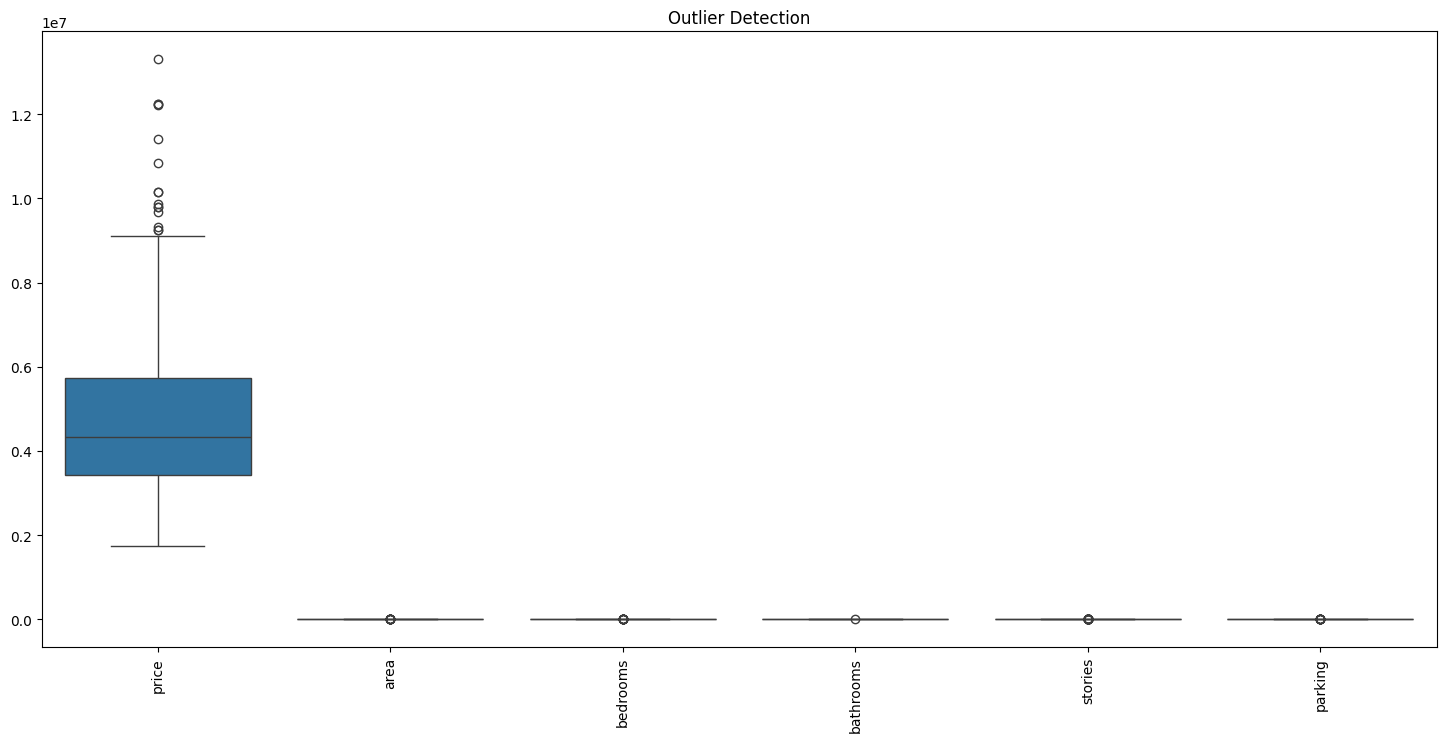

In [ ]:
# STEP 24: To Detect Outliers

plt.figure(figsize=(18,8))

sns.boxplot(data=df[numerical_columns])

plt.xticks(rotation=90)

plt.title("Outlier Detection")

plt.show()


In [ ]:

# STEP 25: Remove Outliers Using IQR

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    df = df[
        (df[column] >= lower_limit) &
        (df[column] <= upper_limit)
    ]

print("Outliers removed successfully!")


# STEP 26: Compare Dataset Size

print("Dataset Shape After Removing Outliers:")

df.shape



Outliers removed successfully!
Dataset Shape After Removing Outliers:


(352, 13)

In [ ]:
# STEP 27: Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:

    df[column] = encoder.fit_transform(df[column])

print("Categorical variables encoded successfully!")


Categorical variables encoded successfully!


In [ ]:
# STEP 28: Verify Data Types

df.info()

# STEP 29: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_to_scale = df.drop(columns=["price"]).columns

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Feature scaling completed successfully!")


<class 'pandas.core.frame.DataFrame'>
Index: 352 entries, 68 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             352 non-null    int64
 1   area              352 non-null    int64
 2   bedrooms          352 non-null    int64
 3   bathrooms         352 non-null    int64
 4   stories           352 non-null    int64
 5   mainroad          352 non-null    int64
 6   guestroom         352 non-null    int64
 7   basement          352 non-null    int64
 8   hotwaterheating   352 non-null    int64
 9   airconditioning   352 non-null    int64
 10  parking           352 non-null    int64
 11  prefarea          352 non-null    int64
 12  furnishingstatus  352 non-null    int64
dtypes: int64(13)
memory usage: 38.5 KB
Feature scaling completed successfully!


In [ ]:
# STEP 30: View Cleaned Dataset

df.head()


# STEP 31: Final Dataset Information

df.info()


# STEP 32: Save the Cleaned Dataset

df.to_csv("House_Prices_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")



# STEP 33: Download the Cleaned Dataset

from google.colab import files

files.download("House_Prices_Cleaned.csv")



<class 'pandas.core.frame.DataFrame'>
Index: 352 entries, 68 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             352 non-null    int64  
 1   area              352 non-null    float64
 2   bedrooms          352 non-null    float64
 3   bathrooms         352 non-null    float64
 4   stories           352 non-null    float64
 5   mainroad          352 non-null    float64
 6   guestroom         352 non-null    float64
 7   basement          352 non-null    float64
 8   hotwaterheating   352 non-null    float64
 9   airconditioning   352 non-null    float64
 10  parking           352 non-null    float64
 11  prefarea          352 non-null    float64
 12  furnishingstatus  352 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 38.5 KB
Cleaned dataset saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# STEP 34: Data Preprocessing Summary


The following preprocessing steps were completed:

- Removed columns with more than 40% missing values.
- Filled missing numerical values using the median.
- Filled missing categorical values using the mode.
- Removed duplicate records.
- Detected and removed outliers using the IQR method.
- Encoded categorical variables using Label Encoding.
- Standardized numerical features using StandardScaler.
- Saved the cleaned dataset for exploratory data analysis and machine learning.


# House Price Prediction Using Machine Learning

- Level 1 – Task 3

# Exploratory Data Analysis (EDA)



In [ ]:
# STEP 1: Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:

import os
import pandas as pd

# Define the path to the folder
Codveda_folder_path = '/content/drive/My Drive/Codveda'

# Check files
files_in_Codveda = os.listdir(Codveda_folder_path)
print(files_in_Codveda)

# Combine the folder path with the specific CSV file name
file_path = os.path.join(Codveda_folder_path, 'House_Prices_Cleaned.csv')

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

['Housing.csv', 'House_Prices_Cleaned.csv']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,6860000,0.973434,0.413675,0.0,-0.909559,0.448737,-0.406894,-0.67420,-0.195827,1.843909,0.651590,-0.502662,-1.563924
1,6650000,-0.287773,0.413675,0.0,0.707435,0.448737,-0.406894,1.48324,5.106557,-0.542326,0.651590,-0.502662,-1.563924
2,6650000,0.780392,0.413675,0.0,-0.909559,0.448737,2.457641,1.48324,-0.195827,1.843909,1.985076,1.989409,-1.563924
3,6629000,0.973434,0.413675,0.0,0.707435,0.448737,-0.406894,-0.67420,5.106557,-0.542326,0.651590,1.989409,-0.234211
4,6510000,-0.467946,0.413675,0.0,0.707435,0.448737,-0.406894,-0.67420,5.106557,-0.542326,1.985076,-0.502662,-0.234211


In [ ]:
# STEP 5: Summary Statistics

df.describe().T


# STEP 6: Check for Missing Values

df.isnull().sum().sum()



np.int64(0)

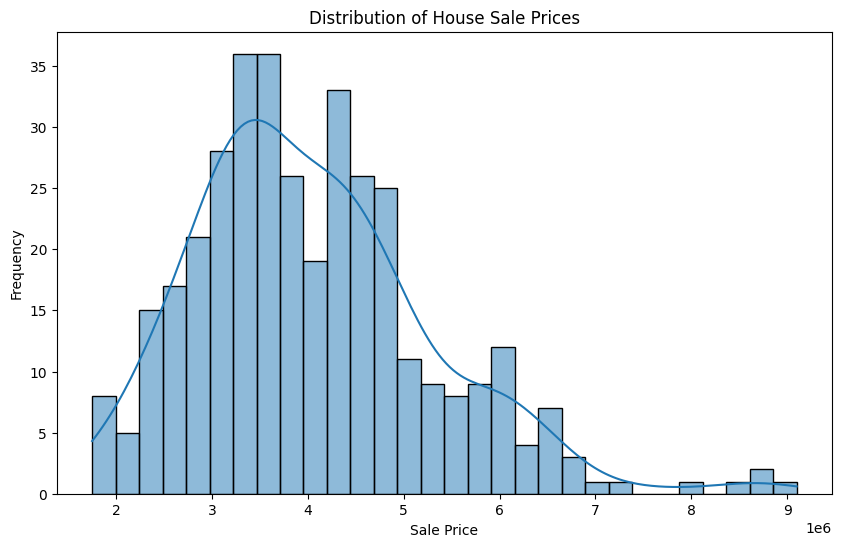

In [ ]:
# STEP 7: Distribution of Price

plt.figure(figsize=(10,6))

sns.histplot(df["price"],
             kde=True,
             bins=30)

plt.title("Distribution of House Sale Prices")

plt.xlabel("Sale Price")

plt.ylabel("Frequency")

plt.show()


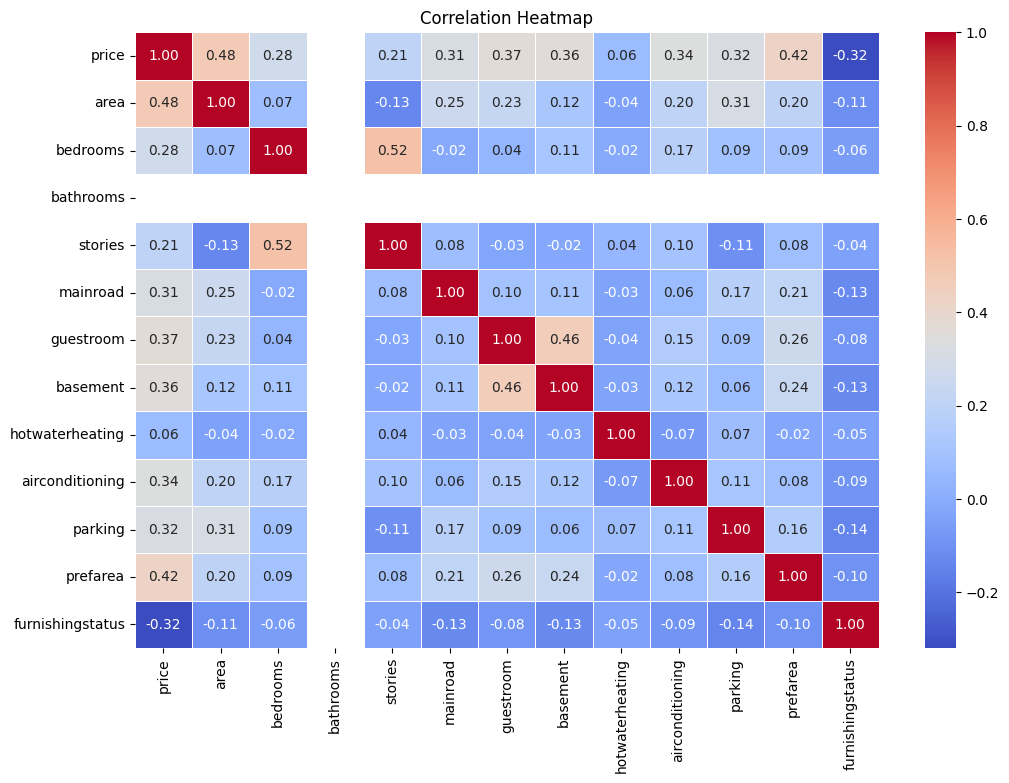

In [ ]:
# STEP 8: Correlation Heatmap

correlation_matrix = df.corr()

correlation_matrix


plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
        annot=True,
            cmap="coolwarm",
                fmt=".2f",
                    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()


In [ ]:
# STEP 9: Features Most Correlated with Price

price_corr = correlation_matrix["price"].sort_values(ascending=False)

price_corr


,price
price,1.000000
area,0.476393
prefarea,0.424162
guestroom,0.368699
basement,0.357539
airconditioning,0.336734
parking,0.315731
mainroad,0.309817
bedrooms,0.277656
stories,0.205772


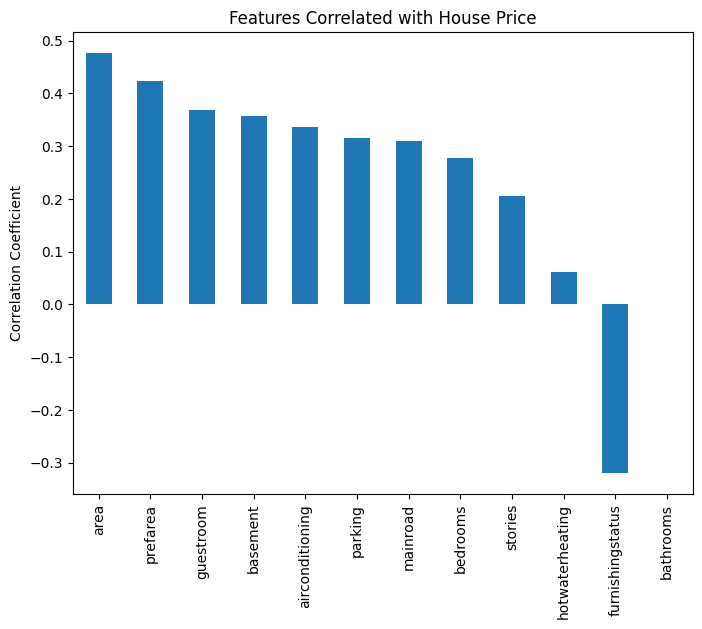

In [ ]:
# STEP 10: Visualize Correlation with Price

plt.figure(figsize=(8,6))

price_corr.drop("price").plot(kind="bar")

plt.title("Features Correlated with House Price")

plt.ylabel("Correlation Coefficient")

plt.show()


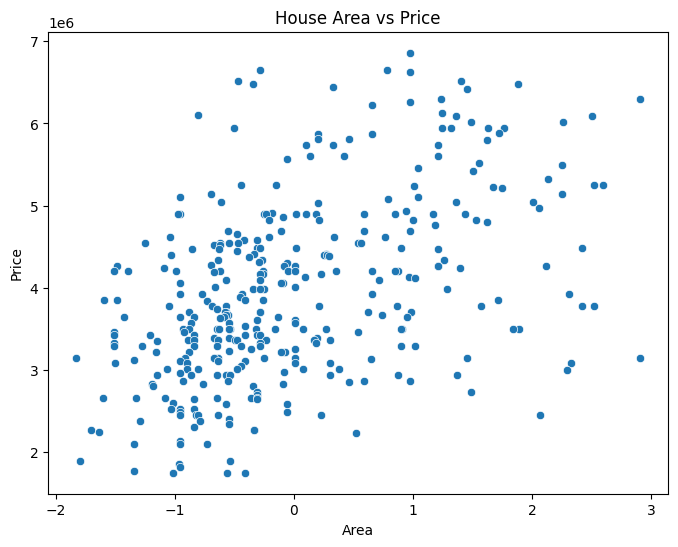

In [ ]:
# STEP 11: Area vs Price

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="area",
        y="price",
            data=df
)

plt.title("House Area vs Price")

plt.xlabel("Area")

plt.ylabel("Price")

plt.show()


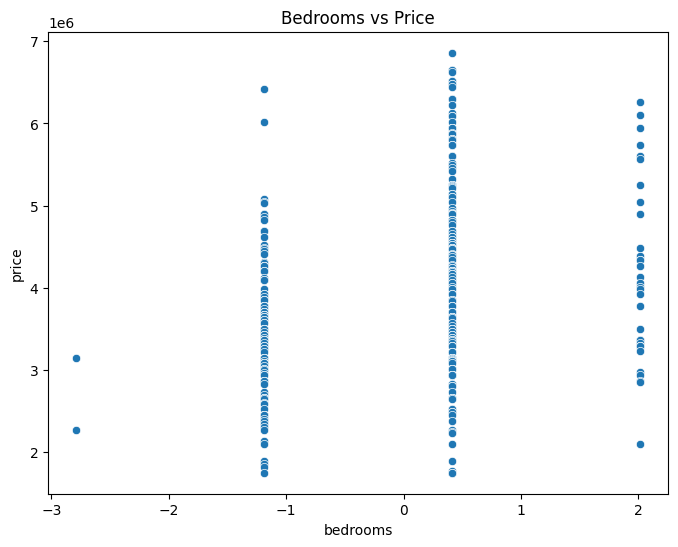

In [ ]:
# STEP 12: Bedrooms vs Price

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="bedrooms",
        y="price",
            data=df
)

plt.title("Bedrooms vs Price")

plt.show()


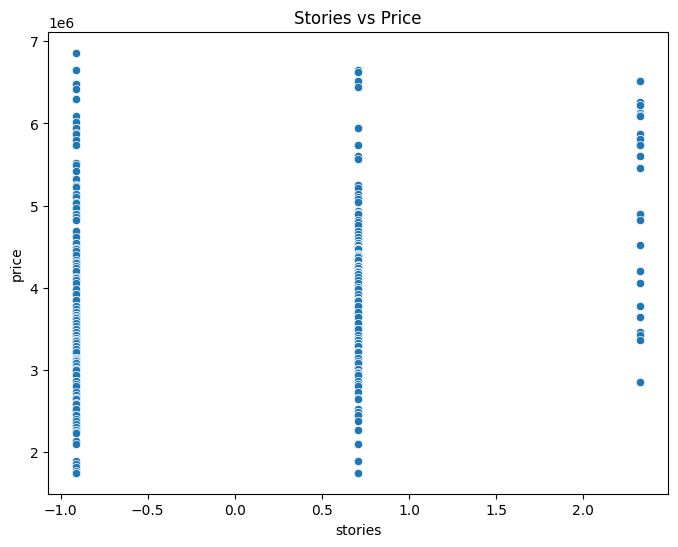

In [ ]:
# STEP 13: Stories vs Price

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="stories",
        y="price",
            data=df
)

plt.title("Stories vs Price")

plt.show()


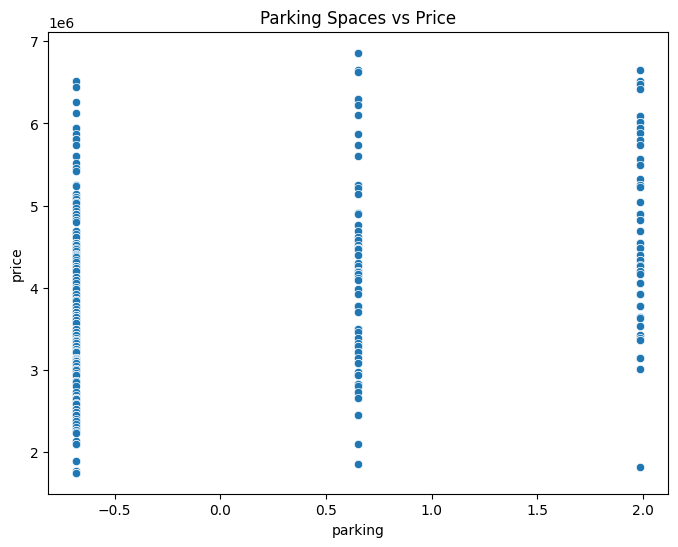

In [ ]:
# STEP 14: Parking vs Price

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="parking",
        y="price",
            data=df
)

plt.title("Parking Spaces vs Price")

plt.show()


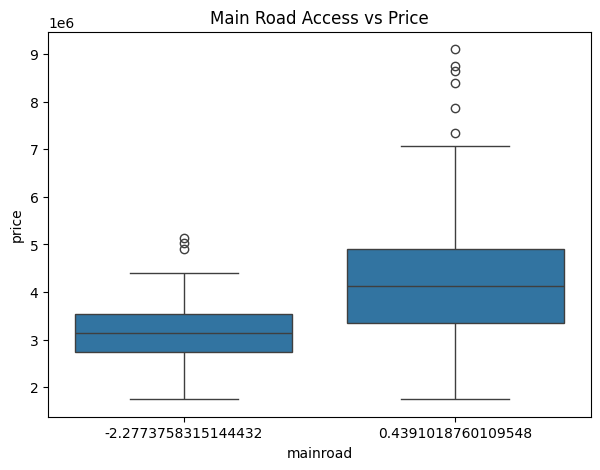

In [ ]:

# STEP 15: Main Road Access vs Price

plt.figure(figsize=(7,5))

sns.boxplot(
    x="mainroad",
        y="price",
            data=df
)

plt.title("Main Road Access vs Price")

plt.show()


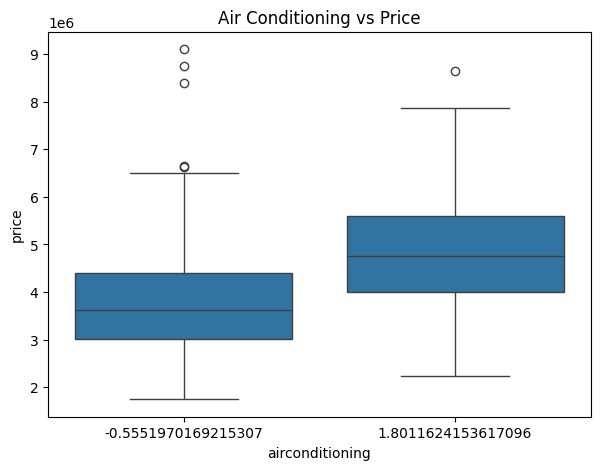

In [ ]:
# STEP 16: Air Conditioning vs Price

plt.figure(figsize=(7,5))

sns.boxplot(
    x="airconditioning",
        y="price",
            data=df
)

plt.title("Air Conditioning vs Price")

plt.show()


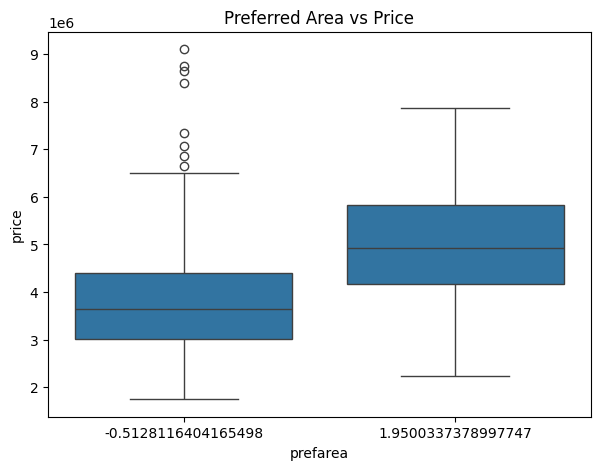

In [ ]:
# STEP 17: Preferred Area vs Price

plt.figure(figsize=(7,5))

sns.boxplot(
    x="prefarea",
        y="price",
            data=df
)

plt.title("Preferred Area vs Price")

plt.show()


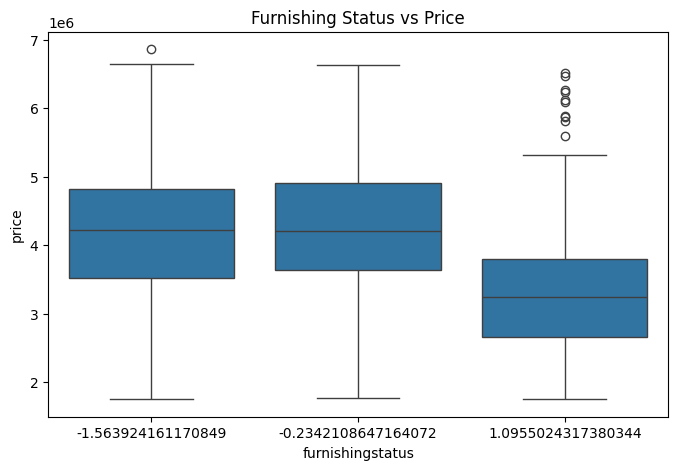

In [ ]:
# STEP 18: Furnishing Status vs Price

plt.figure(figsize=(8,5))

sns.boxplot(
    x="furnishingstatus",
        y="price",
            data=df
)

plt.title("Furnishing Status vs Price")

plt.show()


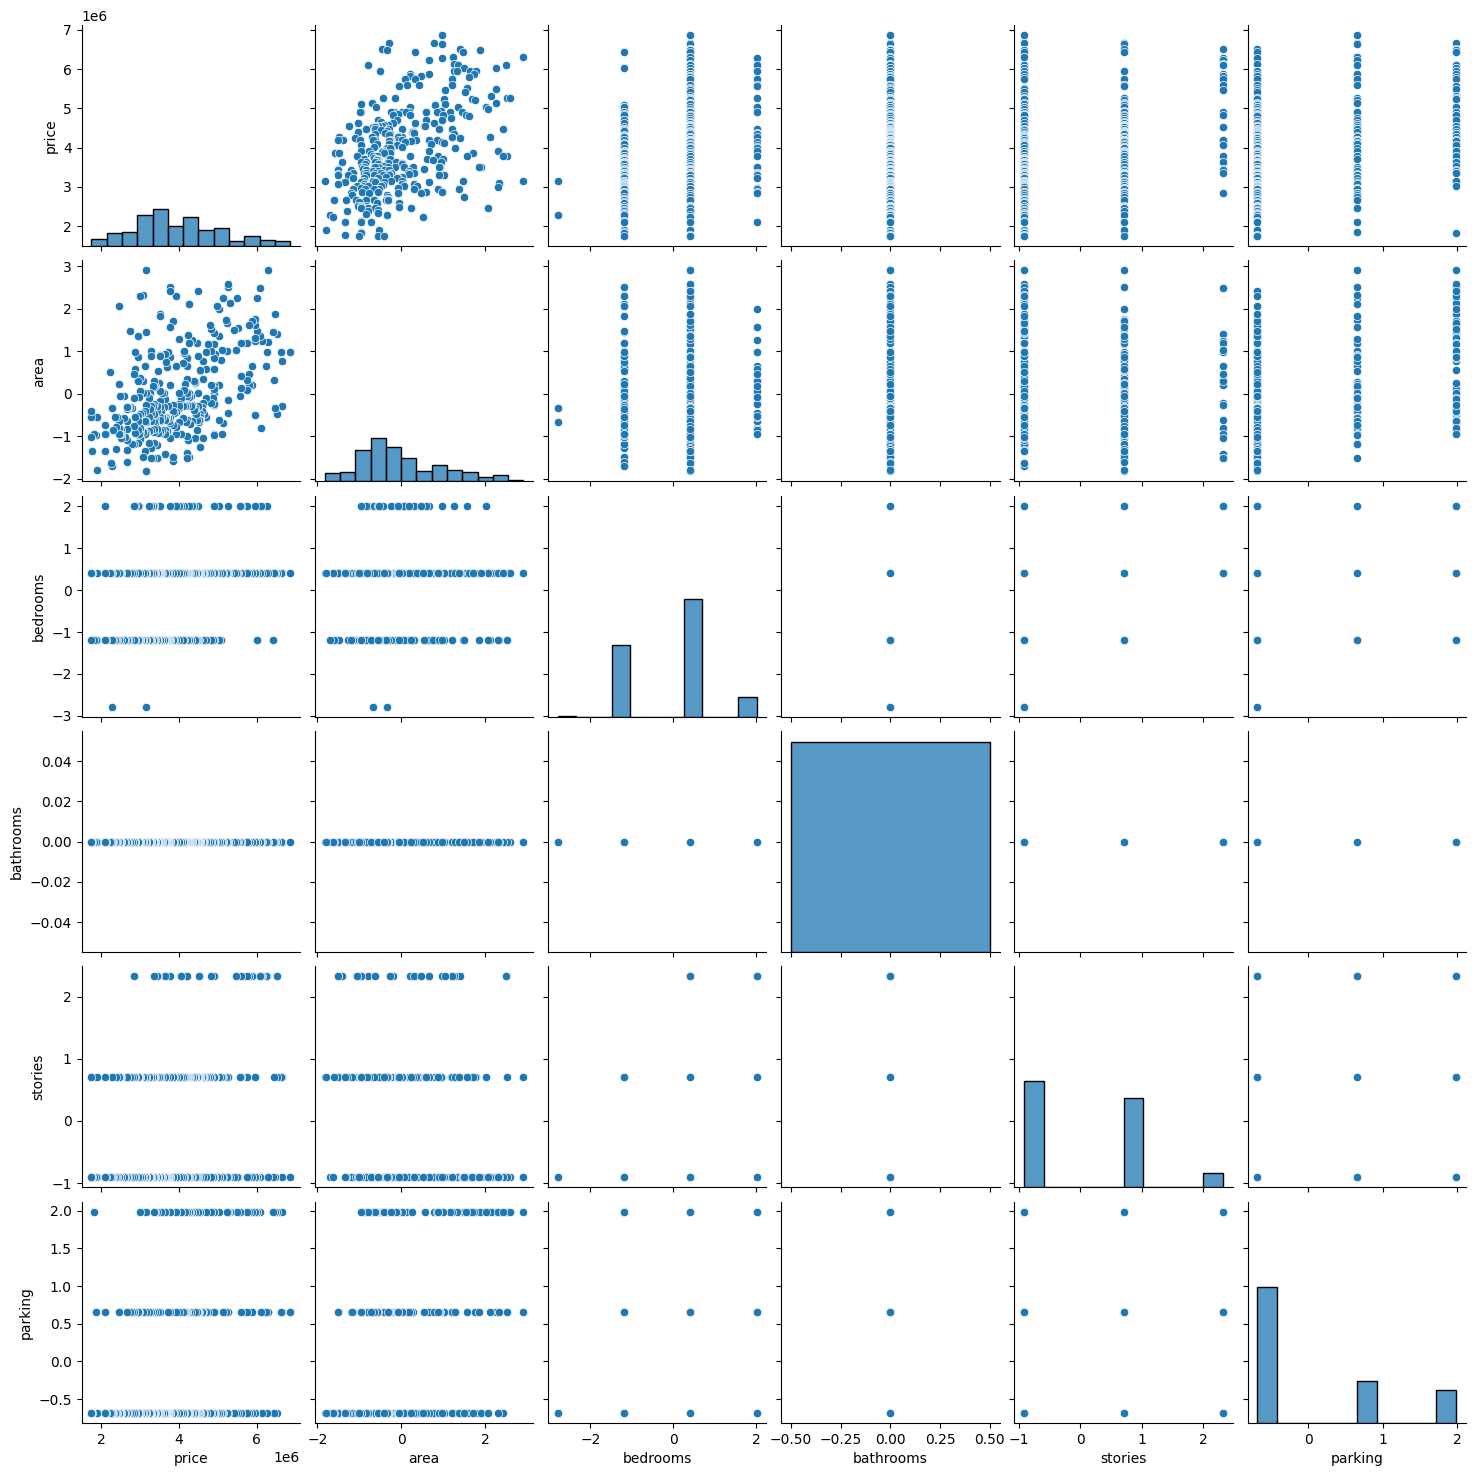

In [ ]:
# STEP 19: Pairplot of Important Features

selected_features = [
    "price",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

sns.pairplot(df[selected_features])

plt.show()


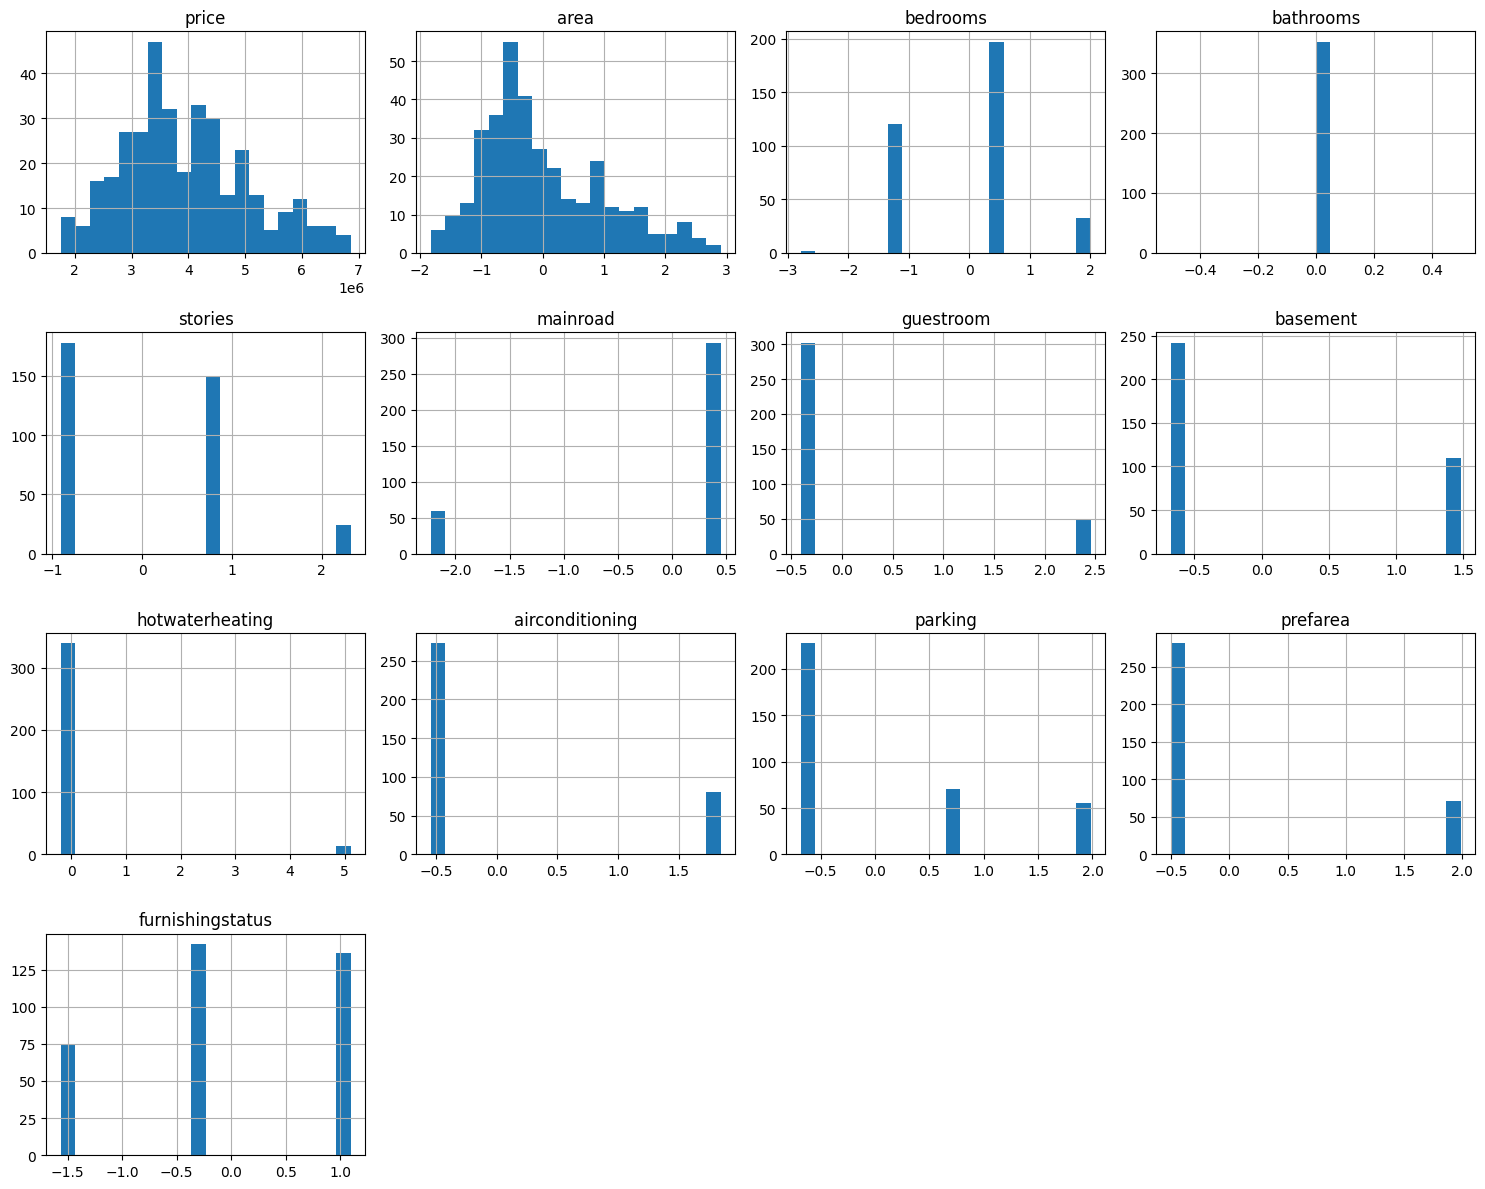

In [ ]:
# STEP 20: Distribution of All Features

df.hist(
    figsize=(15,12),
        bins=20
)

plt.tight_layout()

plt.show()



# STEP 31: FINAL EDA SUMMARY

# Key Findings

## Summary of Exploratory Data Analysis

- The dataset contains **13 variables**, including the target variable (`price`) and 12 predictor variables.

- Correlation analysis identified the variables most strongly associated with house prices.

- Larger house areas generally correspond to higher selling prices.

- Houses with more bedrooms, bathrooms, stories, and parking spaces tend to command higher prices.

- Houses located in preferred areas and those with air conditioning generally have higher market values.

- The dataset is clean and suitable for predictive modelling.

- These findings provide a strong foundation for developing regression and classification models in the next stage of the project.
